# Employment-Only Prediction Model (Anonymized Data)

This notebook builds a reproducible **employment-only** prediction pipeline from anonymized program data.

Targets:
- `jobs_created_3m` from endline employment data (`job_created`)
- `jobs_lost_3m` derived conservatively as `max(baseline_job_created - endline_job_created, 0)` because direct job-loss labels are not available in the anonymized survey schema

It uses a chronological split by `survey_date` and exports employment-only artifacts.

In [1]:
import io
import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

def find_ml_dir(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for c in candidates:
        if (c / "ml" / "Anomynized data").exists():
            return c / "ml"
        if (c / "Anomynized data").exists():
            return c
    raise FileNotFoundError(
        f"Could not locate ML data directory from {start}. Expected an 'ml/Anomynized data' or 'Anomynized data' folder in current/parent paths."
    )

def load_csv_with_fallback(path: Path) -> pd.DataFrame:
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raw = path.read_bytes()
    text = raw.decode("utf-8", errors="replace")
    return pd.read_csv(io.StringIO(text))

BASE_DIR = Path.cwd().resolve()
ML_DIR = find_ml_dir(BASE_DIR)
ANON_DIR = ML_DIR / "Anomynized data" / "Anomynized data" / "Anomynized data"

ARTIFACTS_DIR = ML_DIR / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"
PREDICTIONS_DIR = ARTIFACTS_DIR / "predictions"
CHARTS_DIR = ML_DIR / "charts"

for d in [ARTIFACTS_DIR, MODELS_DIR, METRICS_DIR, PREDICTIONS_DIR, CHARTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INVESTMENT_PATH = ANON_DIR / "Investment data_all clients_RW-KE-ET-SS_2021-2025_Inkomoko.csv"
BASELINE_PATH = ANON_DIR / "baseline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv"
ENDLINE_PATH = ANON_DIR / "endline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv"

TARGETS_EMPLOYMENT = ["jobs_created_3m", "jobs_lost_3m"]

print(f"BASE_DIR: {BASE_DIR}")
print(f"ML_DIR: {ML_DIR}")
print(f"Anonymized data dir exists: {ANON_DIR.exists()} -> {ANON_DIR}")
print(f"Investment exists: {INVESTMENT_PATH.exists()} -> {INVESTMENT_PATH}")
print(f"Baseline exists: {BASELINE_PATH.exists()} -> {BASELINE_PATH}")
print(f"Endline exists: {ENDLINE_PATH.exists()} -> {ENDLINE_PATH}")

BASE_DIR: /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/notebooks
ML_DIR: /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml
Anonymized data dir exists: True -> /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/Anomynized data/Anomynized data/Anomynized data
Investment exists: True -> /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/Anomynized data/Anomynized data/Anomynized data/Investment data_all clients_RW-KE-ET-SS_2021-2025_Inkomoko.csv
Baseline exists: True -> /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/Anomynized data/Anomynized data/Anomynized data/baseline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv
Endline exists: True -> /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/Anomynized data/Anomynized data/Anomynized dat

In [2]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = []
    seen = {}
    for c in df.columns:
        name = str(c).strip()
        if name in seen:
            seen[name] += 1
            name = f"{name}_{seen[name]}"
        else:
            seen[name] = 0
        cols.append(name)
    out = df.copy()
    out.columns = cols
    return out

def parse_dates(df: pd.DataFrame, date_cols: List[str], dayfirst: bool = False) -> pd.DataFrame:
    out = df.copy()
    for c in date_cols:
        if c in out.columns:
            out[c] = pd.to_datetime(out[c], errors="coerce", dayfirst=dayfirst)
    return out

def to_num(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("#REF!", "", regex=False)
                .str.replace("$", "", regex=False)
            )
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

investment_df = load_csv_with_fallback(INVESTMENT_PATH)
baseline_df = load_csv_with_fallback(BASELINE_PATH)
endline_df = load_csv_with_fallback(ENDLINE_PATH)

investment = normalize_columns(investment_df)
baseline = normalize_columns(baseline_df)
endline = normalize_columns(endline_df)

investment = parse_dates(investment, ["submissionDate", "approvalDate", "disbursementDate", "lastPaymentDate"], dayfirst=False)
baseline = parse_dates(baseline, ["survey_date"], dayfirst=True)
endline = parse_dates(endline, ["survey_date"], dayfirst=True)

inv_num_cols = [
    "daysInArrears", "installmentInArrears", "approvedAmount", "disbursedAmount",
    "actualPaymentAmount", "amountPastDue", "scheduledPaymentAmount", "principalPaid",
    "termsDuration", "cycle", "age", "DisbursementYear",
    "currentBalance", "principalBalance", "interestBalance", "feesBalance",
]
baseline_num_cols = ["job_created", "revenue", "hh_expense", "monthly_customer", "number_of_people_reponsible", "age"]
endline_num_cols = baseline_num_cols + ["nps_detractor", "nps_passive", "nps_promoter", "satisfied_yes", "satisfied_no"]

investment = to_num(investment, inv_num_cols)
baseline = to_num(baseline, baseline_num_cols)
endline = to_num(endline, endline_num_cols)

for df, col in [(investment, "BaselineEndlineClientId"), (investment, "ClientId"), (baseline, "client_id"), (endline, "client_id")]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

loan_sort_col = "disbursementDate" if "disbursementDate" in investment.columns else "approvalDate"
investment = investment.sort_values(["ClientId", loan_sort_col])
loan_latest = investment.groupby("ClientId", as_index=False).tail(1).copy()

loan_latest["repayment_ratio"] = loan_latest["actualPaymentAmount"] / loan_latest["scheduledPaymentAmount"].replace(0, np.nan)
loan_latest["utilization_ratio"] = loan_latest["disbursedAmount"] / loan_latest["approvedAmount"].replace(0, np.nan)
loan_latest["past_due_ratio"] = loan_latest["amountPastDue"] / loan_latest["scheduledPaymentAmount"].replace(0, np.nan)
loan_latest["principal_completion_ratio"] = loan_latest["principalPaid"] / loan_latest["disbursedAmount"].replace(0, np.nan)

baseline_ctx = baseline[[c for c in ["client_id", "survey_date", "job_created", "revenue", "hh_expense", "monthly_customer", "business_sector", "business_location", "education_level", "gender", "strata", "have_bank_account", "is_business_registered"] if c in baseline.columns]].copy()
baseline_ctx = baseline_ctx.rename(columns={"survey_date": "baseline_survey_date", "job_created": "baseline_job_created", "revenue": "baseline_revenue", "hh_expense": "baseline_hh_expense"})

endline_ctx = endline[[c for c in ["client_id", "survey_date", "job_created", "revenue", "hh_expense", "monthly_customer", "business_sector", "business_location", "education_level", "gender", "strata", "have_bank_account", "is_business_registered", "nps_detractor", "nps_passive", "nps_promoter", "satisfied_yes", "satisfied_no"] if c in endline.columns]].copy()
endline_ctx = endline_ctx.rename(columns={"survey_date": "endline_survey_date", "job_created": "endline_job_created", "revenue": "endline_revenue", "hh_expense": "endline_hh_expense"})

survey_ctx = baseline_ctx.merge(endline_ctx, on="client_id", how="outer", suffixes=("_baseline", "_endline"))

model_df = loan_latest.merge(
    survey_ctx,
    left_on="BaselineEndlineClientId",
    right_on="client_id",
    how="left",
)

model_df["survey_date"] = model_df["endline_survey_date"].where(model_df["endline_survey_date"].notna(), model_df["baseline_survey_date"])
model_df["jobs_created_3m"] = pd.to_numeric(model_df.get("endline_job_created"), errors="coerce").clip(lower=0)
baseline_jobs = pd.to_numeric(model_df.get("baseline_job_created"), errors="coerce")
endline_jobs = pd.to_numeric(model_df.get("endline_job_created"), errors="coerce")
model_df["jobs_lost_3m"] = (baseline_jobs - endline_jobs).clip(lower=0).fillna(0)

model_df["jobs_created_to_expense_ratio"] = model_df["jobs_created_3m"] / pd.to_numeric(model_df.get("endline_hh_expense"), errors="coerce").replace(0, np.nan)
model_df["revenue_to_expense_ratio"] = pd.to_numeric(model_df.get("endline_revenue"), errors="coerce") / pd.to_numeric(model_df.get("endline_hh_expense"), errors="coerce").replace(0, np.nan)

join_coverage = model_df["client_id"].notna().mean() if "client_id" in model_df.columns else 0.0
created_coverage = model_df["jobs_created_3m"].notna().mean()
print(f"Join coverage (loan->survey): {join_coverage:.2%}")
print(f"Target coverage (jobs_created_3m): {created_coverage:.2%}")

for c in model_df.columns:
    if hasattr(model_df[c], "dtype") and model_df[c].dtype.kind in "fiu":
        model_df[c] = model_df[c].replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(subset=["survey_date", "jobs_created_3m"]).sort_values("survey_date").reset_index(drop=True)

if len(model_df) < 10:
    raise ValueError("Not enough rows after filtering to train a stable employment model (need at least 10 rows).")

split_idx = min(max(1, int(len(model_df) * 0.8)), len(model_df) - 1)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

drop_cols = {
    "survey_date", "client_id", "ClientId", "BaselineEndlineClientId", "loanNumber",
    "baseline_survey_date", "endline_survey_date",
    "baseline_job_created", "endline_job_created",
    "jobs_created_3m", "jobs_lost_3m",
}
feature_cols = [c for c in model_df.columns if c not in drop_cols]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

if len(num_cols) + len(cat_cols) == 0:
    raise ValueError("No usable feature columns found after preprocessing and leakage filtering.")

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols),
    ],
    remainder="drop",
)

print(f"Rows total/train/test: {len(model_df)} / {len(train_df)} / {len(test_df)}")
print(f"Features: {len(feature_cols)} (num={len(num_cols)}, cat={len(cat_cols)})")
display(model_df[["survey_date", "jobs_created_3m", "jobs_lost_3m", "ClientId", "BaselineEndlineClientId"]].head(5))

Join coverage (loan->survey): 8.75%
Target coverage (jobs_created_3m): 8.66%
Rows total/train/test: 1822 / 1457 / 365
Features: 81 (num=51, cat=30)


,survey_date,jobs_created_3m,jobs_lost_3m,ClientId,BaselineEndlineClientId
0,2022-05-12,13.0,0.0,B1F2E92408DFFB52,F3189A46B6A3C8EEBB5C
1,2022-05-12,1.0,0.0,EB0BC55D7D0E1075,8C990A2BB3661B85BFCA
2,2022-05-12,4.0,0.0,1A5CABDC8A2E87FA,9DCD66D1D1978914EAC8
3,2022-05-12,13.0,0.0,39313AA6958BEBF3,F3189A46B6A3C8EEBB5C
4,2022-05-12,2.0,0.0,7E24E674AB982FFB,E7E5558BD4A5C15CAFC8


In [3]:
# Train one model per employment target
employment_models = {}
employment_preds = {}
metrics_rows = []

for tgt in TARGETS_EMPLOYMENT:
    y_train = train_df[tgt].fillna(0).clip(lower=0)
    y_test = test_df[tgt].fillna(0).clip(lower=0)

    model = Pipeline([
        ("prep", preprocess),
        ("reg", RandomForestRegressor(n_estimators=350, random_state=SEED, n_jobs=-1)),
    ])
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_test), 0, None)

    employment_models[tgt] = model
    employment_preds[tgt] = pred

    metrics_rows.append({
        "target": tgt,
        "rmse": round(float(np.sqrt(mean_squared_error(y_test, pred))), 6),
        "mae": round(float(mean_absolute_error(y_test, pred)), 6),
        "rows_train": len(train_df),
        "rows_test": len(test_df),
    })

employment_metrics_df = pd.DataFrame(metrics_rows)
display(employment_metrics_df)

,target,rmse,mae,rows_train,rows_test
0,jobs_created_3m,3.511198,1.805182,1457,365
1,jobs_lost_3m,2.293633,1.157926,1457,365


Saved chart to: /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/charts/employment_backtest.png


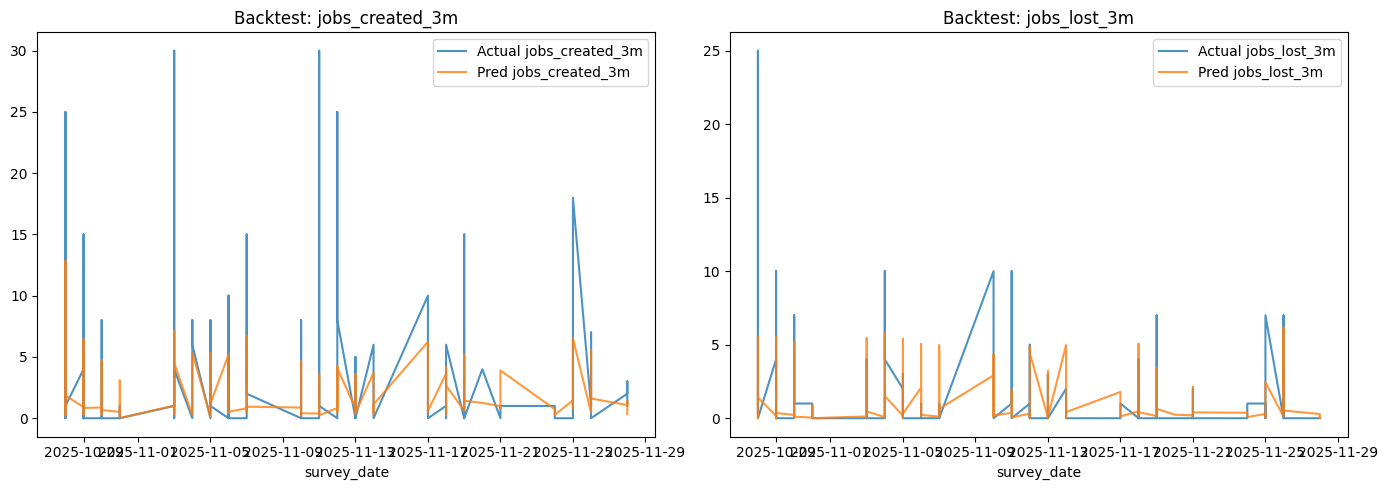

In [4]:
# Simple diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, tgt in enumerate(TARGETS_EMPLOYMENT):
    axes[i].plot(test_df["survey_date"], test_df[tgt].fillna(0).values, label=f"Actual {tgt}", alpha=0.8)
    axes[i].plot(test_df["survey_date"], employment_preds[tgt], label=f"Pred {tgt}", alpha=0.8)
    axes[i].set_title(f"Backtest: {tgt}")
    axes[i].set_xlabel("survey_date")
    axes[i].legend()

plt.tight_layout()
out_path = CHARTS_DIR / "employment_backtest.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved chart to: {out_path.resolve()}")
plt.show()

In [5]:
# Export employment-only artifacts
base_export = model_df.iloc[X_test.index][["ClientId", "BaselineEndlineClientId", "survey_date"] + TARGETS_EMPLOYMENT].reset_index(drop=True).copy()
employment_export = base_export

for tgt in TARGETS_EMPLOYMENT:
    employment_export[f"pred_{tgt}"] = employment_preds[tgt]
    joblib.dump(employment_models[tgt], MODELS_DIR / f"employment_{tgt}_model.joblib")

employment_metrics_df.to_csv(METRICS_DIR / "employment_model_metrics.csv", index=False)
employment_export.to_csv(PREDICTIONS_DIR / "employment_predictions_test.csv", index=False)

print("Saved:")
print(" -", METRICS_DIR / "employment_model_metrics.csv")
print(" -", PREDICTIONS_DIR / "employment_predictions_test.csv")
print(" -", CHARTS_DIR / "employment_backtest.png")
for tgt in TARGETS_EMPLOYMENT:
    print(" -", MODELS_DIR / f"employment_{tgt}_model.joblib")

display(employment_export.head())

Saved:
 - /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/metrics/employment_model_metrics.csv
 - /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/predictions/employment_predictions_test.csv
 - /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/charts/employment_backtest.png
 - /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/models/employment_jobs_created_3m_model.joblib
 - /home/tr3p0l3m/Course Simulations/SEMESTER 4 SIMS/CAPSTONE/inkomoko-earlywarning-system/ml/artifacts/models/employment_jobs_lost_3m_model.joblib


,ClientId,BaselineEndlineClientId,survey_date,jobs_created_3m,jobs_lost_3m,pred_jobs_created_3m,pred_jobs_lost_3m
0,30D55C080DD7CD41,F9793D0A1FEFD361B41F,2025-10-28,2.0,1.0,3.522857,0.480000
1,12ADC5CC1B00EF12,6CCE323127C2B03EA94E,2025-10-28,2.0,5.0,2.580000,1.302857
2,4F7F4CE86E055D34,E06ECAD4D27EE60D4337,2025-10-28,1.0,2.0,2.485714,2.311429
3,B1C54735BF94A1E4,77E0FA7868D0CA23C419,2025-10-28,0.0,1.0,3.488571,0.400000
4,E07DC4C49E3292D7,A34F030C1EE477F8B243,2025-10-28,0.0,0.0,0.654286,0.337143
